<a href="https://colab.research.google.com/github/AndreTownsend/fullstackcostofliving/blob/main/Fullstackcostofliving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install dependencies
!pip install -q wbgapi pandas numpy matplotlib seaborn plotly sqlalchemy

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
from datetime import datetime

import wbgapi as wb

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

from sqlalchemy import create_engine, text

print("✅ Setup complete")

✅ Setup complete


In [3]:
COUNTRIES = [
    'USA','GBR','DEU','FRA','ITA','ESP','CAN','AUS','JPN','KOR',
    'BRA','MEX','ARG','TUR','ZAF','IND','POL','SWE','NLD','CHE'
]

YEARS = list(range(2015, 2024))

def fetch_wb(indicator, label):
    try:
        df = wb.data.DataFrame(
            indicator,
            economy=COUNTRIES,
            time=YEARS,
            labels=True,
            skipBlanks=True
        ).reset_index()

        id_vars = [c for c in df.columns if not c.startswith('YR')]
        df = df.melt(id_vars=id_vars, var_name='year', value_name=label)

        df['year'] = df['year'].str.replace('YR','')
        df['year'] = pd.to_numeric(df['year'], errors='coerce')

        df = df.rename(columns={
            'economy':'country_code',
            'Country':'country_name'
        })

        return df[['country_code','country_name','year', label]].dropna()

    except Exception as e:
        print(f"Error loading {label}: {e}")
        return pd.DataFrame()

print("📡 Fetching data...")

df_inflation = fetch_wb('FP.CPI.TOTL.ZG', 'inflation')
df_gdp       = fetch_wb('NY.GDP.PCAP.CD', 'gdp')
df_unemp     = fetch_wb('SL.UEM.TOTL.ZS', 'unemployment')

df_inflation.head()

📡 Fetching data...


,country_code,country_name,year,inflation
0,CHE,Switzerland,2015,-1.143909
1,NLD,Netherlands,2015,0.600248
2,SWE,Sweden,2015,-0.046785
3,POL,Poland,2015,-0.874126
4,IND,India,2015,4.906973


In [4]:
wage_data = {
    'USA':[2.3,2.9,3.1,3.3,3.5,7.9,4.7,5.1,4.3],
    'GBR':[2.0,2.4,2.7,3.2,3.8,6.8,5.2,6.9,6.1],
    'DEU':[2.5,2.7,2.8,3.0,2.8,3.2,3.4,5.3,5.8],
    'JPN':[0.5,0.6,0.4,0.8,1.0,1.5,0.9,1.8,2.5],
}

rows = []
for c, vals in wage_data.items():
    for i, y in enumerate(range(2015, 2024)):
        rows.append([c, y, vals[i]])

df_wage = pd.DataFrame(rows, columns=['country_code','year','wage_growth'])
df_wage.head()

,country_code,year,wage_growth
0,USA,2015,2.3
1,USA,2016,2.9
2,USA,2017,3.1
3,USA,2018,3.3
4,USA,2019,3.5


In [5]:
housing = [
    ['USA',70.5,28.5],
    ['GBR',67.2,32.1],
    ['DEU',65.8,27.3],
    ['JPN',64.5,20.1],
]

df_housing = pd.DataFrame(housing, columns=[
    'country_code','cost_index','rent_pct'
])

df_housing

,country_code,cost_index,rent_pct
0,USA,70.5,28.5
1,GBR,67.2,32.1
2,DEU,65.8,27.3
3,JPN,64.5,20.1


In [6]:
df = df_wage.merge(df_inflation[['country_code','year','inflation']],
                   on=['country_code','year'], how='left')

df['real_wage'] = df['wage_growth'] - df['inflation']

df['wage_squeezed'] = df['real_wage'] < 0

df = df.sort_values(['country_code','year'])
df['cum_real_wage'] = df.groupby('country_code')['real_wage'].cumsum()

df.head()

,country_code,year,wage_growth,inflation,real_wage,wage_squeezed,cum_real_wage
18,DEU,2015,2.5,0.514426,1.985574,False,1.985574
19,DEU,2016,2.7,0.491747,2.208253,False,4.193827
20,DEU,2017,2.8,1.509495,1.290505,False,5.484332
21,DEU,2018,3.0,1.732169,1.267831,False,6.752163
22,DEU,2019,2.8,1.445660,1.354340,False,8.106503


In [7]:
df_2023 = df[df['year']==2023].copy()
df_2023 = df_2023.merge(df_housing, on='country_code', how='left')

def norm(s):
    s = s.fillna(s.median())
    return (s - s.min()) / (s.max() - s.min())

df_2023['pressure'] = (
    norm(df_2023['inflation']) * 0.4 +
    norm(df_2023['rent_pct']) * 0.3 +
    norm(-df_2023['real_wage']) * 0.3
) * 100

df_2023[['country_code','pressure']].sort_values('pressure', ascending=False)

,country_code,pressure
1,GBR,97.662315
0,DEU,58.789402
3,USA,30.622743
2,JPN,30.000000


In [8]:
engine = create_engine('sqlite:///cost.db')

df.to_sql('panel', engine, if_exists='replace', index=False)
df_2023.to_sql('snapshot', engine, if_exists='replace', index=False)

query = """
SELECT country_code,
       AVG(real_wage) as avg_real_wage
FROM panel
GROUP BY country_code
ORDER BY avg_real_wage ASC
"""

pd.read_sql(query, engine)

,country_code,avg_real_wage
0,JPN,0.209158
1,DEU,1.086216
2,USA,1.253812
3,GBR,1.434551


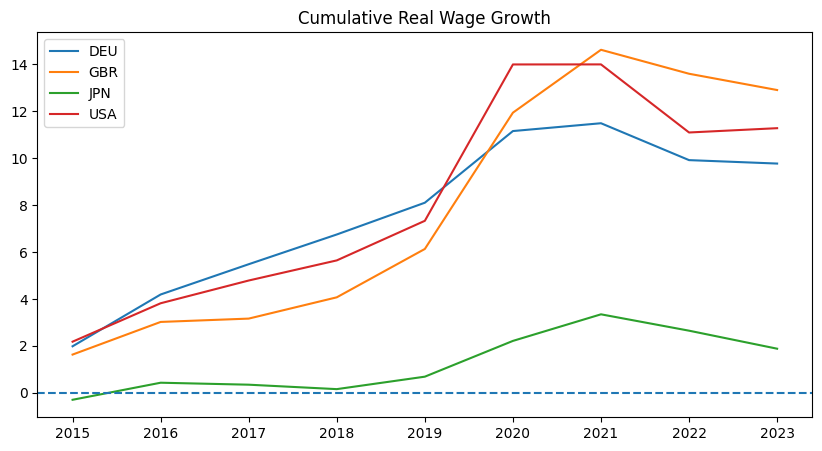

In [9]:
plt.figure(figsize=(10,5))

for c in df['country_code'].unique():
    sub = df[df['country_code']==c]
    plt.plot(sub['year'], sub['cum_real_wage'], label=c)

plt.axhline(0, linestyle='--')
plt.title("Cumulative Real Wage Growth")
plt.legend()
plt.show()

In [10]:
fig = px.choropleth(
    df_2023,
    locations='country_code',
    color='pressure',
    title='Economic Pressure (2023)'
)

fig.show()

In [12]:
df.to_csv('/content/panel.csv', index=False)
df_2023.to_csv('/content/snapshot.csv', index=False)

print("✅ Files exported to /content/")

✅ Files exported to /content/
